# LSTM ve GRU Validation Karşılaştırması

Bu notebook, aynı veri bölünmesi ve hiperparametrelerle eğitilen LSTM ve GRU deneylerinin validation sonuçlarını naive baseline ile karşılaştırır. Kaynak sonuçlar `03_model_training.ipynb` ve `04_gru_training.ipynb` dosyalarındaki sabit seed `42` ile çalıştırılmış deneylerden alınmıştır. Test dönemi bu karşılaştırmaya dahil edilmez.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.style.use("seaborn-v0_8-whitegrid")

## Ortak deney koşulları

- Veri: günlük MSFT kapanış fiyatı
- Hedef: önceki 20 işlem gününden bir sonraki kapanışı tahmin etme
- Bölünme: kronolojik `%70 / %15 / %15`
- Ölçekleyici: yalnızca train döneminde uydurulan MinMax `[-1, 1]`
- Mimari: 2 katman, 32 gizli birim
- Optimizasyon: Adam `0.001`, MSE loss
- Eğitim: 50 epoch, validation kaybına göre en iyi ağırlıkların seçimi
- Validation hedefi: 623 işlem günü (`2021-07-26` - `2024-01-16`)

In [2]:
results = pd.DataFrame(
    [
        {
            "Model": "Naive baseline",
            "MSE (USD²)": 24.8756,
            "RMSE (USD)": 4.9875,
            "MAE (USD)": 3.7967,
            "Parametre": 0,
            "Seçilen epoch": np.nan,
            "Eğitim süresi (sn)": np.nan,
        },
        {
            "Model": "LSTM",
            "MSE (USD²)": 47.0467,
            "RMSE (USD)": 6.8591,
            "MAE (USD)": 5.4549,
            "Parametre": 12_961,
            "Seçilen epoch": 49,
            "Eğitim süresi (sn)": 20.07,
        },
        {
            "Model": "GRU",
            "MSE (USD²)": 44.7492,
            "RMSE (USD)": 6.6895,
            "MAE (USD)": 5.2316,
            "Parametre": 9_729,
            "Seçilen epoch": 50,
            "Eğitim süresi (sn)": 66.29,
        },
    ]
).set_index("Model")

display(results)

,MSE (USD²),RMSE (USD),MAE (USD),Parametre,Seçilen epoch,Eğitim süresi (sn)
Model,,,,,,
Naive baseline,24.8756,4.9875,3.7967,0,NaN,NaN
LSTM,47.0467,6.8591,5.4549,12961,49.0000,20.0700
GRU,44.7492,6.6895,5.2316,9729,50.0000,66.2900


## Validation hata metrikleri

RMSE ve MAE için daha düşük değer daha iyi tahmin performansı anlamına gelir.

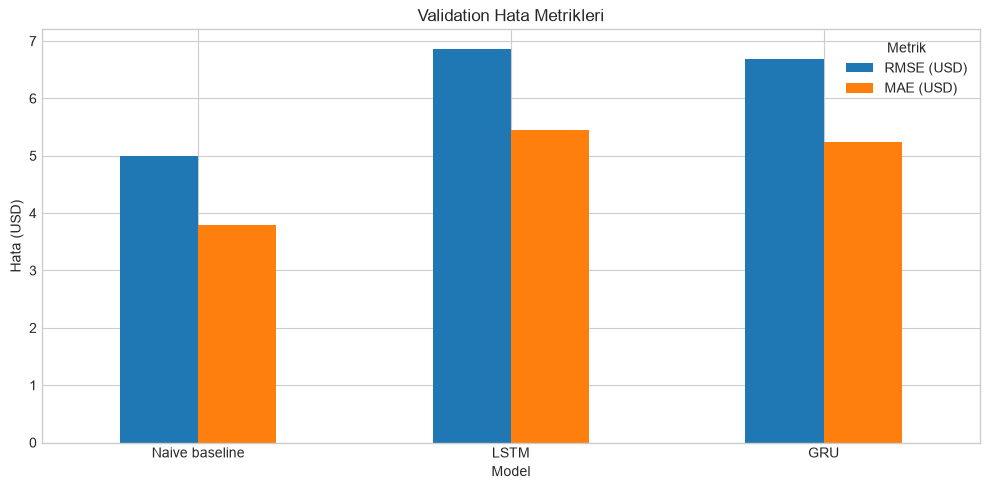

In [3]:
metric_columns = ["RMSE (USD)", "MAE (USD)"]
ax = results[metric_columns].plot(kind="bar", figsize=(10, 5), rot=0)
ax.set_title("Validation Hata Metrikleri")
ax.set_xlabel("Model")
ax.set_ylabel("Hata (USD)")
ax.legend(title="Metrik")
plt.tight_layout()
plt.show()

In [4]:
naive_rmse = results.loc["Naive baseline", "RMSE (USD)"]
relative_results = results.loc[["LSTM", "GRU"], ["RMSE (USD)", "MAE (USD)"]].copy()
relative_results["Naive'a göre RMSE farkı (USD)"] = (
    relative_results["RMSE (USD)"] - naive_rmse
)
relative_results["Naive'a göre RMSE farkı (%)"] = (
    relative_results["Naive'a göre RMSE farkı (USD)"] / naive_rmse * 100
)
display(relative_results)

,RMSE (USD),MAE (USD),Naive'a göre RMSE farkı (USD),Naive'a göre RMSE farkı (%)
Model,,,,
LSTM,6.8591,5.4549,1.8716,37.5258
GRU,6.6895,5.2316,1.7020,34.1253


## Model büyüklüğü ve gözlenen eğitim süresi

Parametre sayısı mimarinin sabit bir özelliğidir. Eğitim süreleri ise tek CPU çalıştırmasından gelir; sistem yükü ve PyTorch uygulama ayrıntılarından etkilenebileceği için genel bir hız sonucu olarak yorumlanmaz.

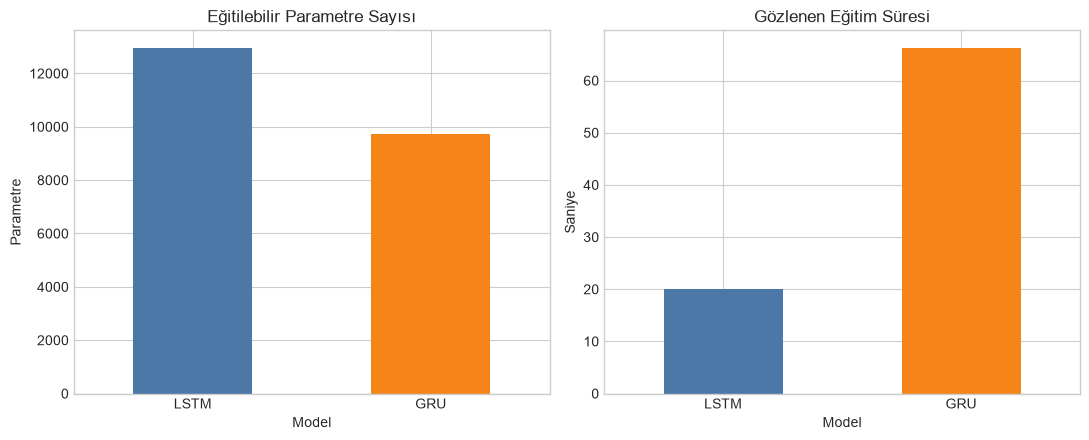

In [5]:
model_results = results.loc[["LSTM", "GRU"]]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

model_results["Parametre"].plot(kind="bar", ax=axes[0], rot=0, color=["#4C78A8", "#F58518"])
axes[0].set_title("Eğitilebilir Parametre Sayısı")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Parametre")

model_results["Eğitim süresi (sn)"].plot(
    kind="bar", ax=axes[1], rot=0, color=["#4C78A8", "#F58518"]
)
axes[1].set_title("Gözlenen Eğitim Süresi")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Saniye")

plt.tight_layout()
plt.show()

## Karşılaştırma bulguları

Aşağıdaki özet yalnızca validation dönemine aittir ve nihai test performansı anlamına gelmez.

In [6]:
recurrent_results = results.loc[["LSTM", "GRU"]]
best_recurrent_model = recurrent_results["RMSE (USD)"].idxmin()
best_recurrent_rmse = recurrent_results.loc[best_recurrent_model, "RMSE (USD)"]
rmse_gap = results.loc["LSTM", "RMSE (USD)"] - results.loc["GRU", "RMSE (USD)"]
parameter_reduction = (
    1 - results.loc["GRU", "Parametre"] / results.loc["LSTM", "Parametre"]
) * 100

assert best_recurrent_rmse > naive_rmse
assert results.loc["GRU", "Parametre"] < results.loc["LSTM", "Parametre"]

print(f"En düşük RNN validation RMSE: {best_recurrent_model} ({best_recurrent_rmse:.4f} USD)")
print(f"LSTM - GRU RMSE farkı: {rmse_gap:+.4f} USD")
print(f"GRU parametre azalması: %{parameter_reduction:.2f}")
print("Naive baseline, iki RNN modelinden de daha düşük validation hatasına sahiptir.")
print("Test dönemine ait tahmin veya metrik kullanılmadı.")

En düşük RNN validation RMSE: GRU (6.6895 USD)
LSTM - GRU RMSE farkı: +0.1696 USD
GRU parametre azalması: %24.94
Naive baseline, iki RNN modelinden de daha düşük validation hatasına sahiptir.
Test dönemine ait tahmin veya metrik kullanılmadı.
